# Visualization and Streamlit Preparation

This notebook prepares the final scored county dataset for interactive visualization and Streamlit deployment.

The goals are to:
- review the final economic risk results
- visualize key patterns across risk categories
- prepare a clean, app-ready dataset for the Streamlit dashboard

In [4]:
# -------------------------------------------------------
# Import Libraries
# -------------------------------------------------------

import pandas as pd
import plotly.express as px

## Load Final Scored Dataset

The dataset with the computed economic risk score and risk categories is loaded.

This dataset will be used to explore results and prepare data for the Streamlit application.

In [8]:
# -------------------------------------------------------
# Load Scored Dataset
# -------------------------------------------------------

df = pd.read_csv("county_risk_scored.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (3222, 11)


,county_fips,county_name,total_population,median_household_income,poverty_rate,unemployment_rate,homeownership_rate,renter_rate,bachelors_or_higher_pct,economic_risk_score,risk_category
0,1001,"Autauga County, Alabama",59947,72481.0,0.112895,0.022899,0.770607,0.229393,0.291385,0.347077,Low Risk
1,1003,"Baldwin County, Alabama",246989,78775.0,0.100927,0.030107,0.776036,0.223964,0.336895,0.328225,Low Risk
2,1005,"Barbour County, Alabama",24643,46042.0,0.213826,0.077736,0.682406,0.317594,0.106273,0.514118,High Risk
3,1007,"Bibb County, Alabama",22130,52541.0,0.224570,0.120808,0.791796,0.208204,0.117256,0.514312,High Risk
4,1009,"Blount County, Alabama",59518,64190.0,0.128601,0.049971,0.809829,0.190171,0.158182,0.405978,Medium Risk


## Top and Bottom Counties by Economic Risk

To better understand the results, we identify:

- The top 10 counties with the highest economic risk
- The top 10 counties with the lowest economic risk

This helps highlight real-world examples of economic disparity across regions.

In [16]:
# -------------------------------------------------------
# Top and Bottom 10 Counties by Economic Risk Score
# -------------------------------------------------------

top_risk = df.sort_values("economic_risk_score", ascending=False).head(10)
low_risk = df.sort_values("economic_risk_score", ascending=True).head(10)

print("Top 10 High-Risk Counties:")
display(top_risk[["county_name", "economic_risk_score", "risk_category"]])

print("\nTop 10 Low-Risk Counties:")
display(low_risk[["county_name", "economic_risk_score", "risk_category"]])

Top 10 High-Risk Counties:


,county_name,economic_risk_score,risk_category
3172,"Guánica Municipio, Puerto Rico",0.776234,High Risk
3144,"Adjuntas Municipio, Puerto Rico",0.743535,High Risk
3193,"Mayagüez Municipio, Puerto Rico",0.734662,High Risk
2414,"Oglala Lakota County, South Dakota",0.725094,High Risk
2423,"Todd County, South Dakota",0.712244,High Risk
3215,"Utuado Municipio, Puerto Rico",0.709318,High Risk
2378,"Corson County, South Dakota",0.695550,High Risk
150,"Lee County, Arkansas",0.693139,High Risk
3166,"Comerío Municipio, Puerto Rico",0.688981,High Risk
2034,"Sioux County, North Dakota",0.684974,High Risk



Top 10 Low-Risk Counties:


,county_name,economic_risk_score,risk_category
2874,"Loudoun County, Virginia",0.109567,Low Risk
1812,"Los Alamos County, New Mexico",0.124009,Low Risk
263,"Douglas County, Colorado",0.156262,Low Risk
2800,"Summit County, Utah",0.160688,Low Risk
446,"Forsyth County, Georgia",0.162223,Low Risk
2523,"Williamson County, Tennessee",0.163402,Low Risk
1207,"Howard County, Maryland",0.166132,Low Risk
1785,"Hunterdon County, New Jersey",0.169099,Low Risk
2850,"Fairfax County, Virginia",0.173403,Low Risk
2065,"Delaware County, Ohio",0.178446,Low Risk


### Observations

- High-risk counties show significantly higher economic risk scores
- Low-risk counties have much lower scores and stronger economic conditions

This comparison highlights the range of economic conditions across U.S. counties and provides concrete examples of areas at different risk levels.

This analysis supports:

**Which U.S. counties are at the highest risk of economic decline based on the constructed economic risk score?**

## Visualization of Highest and Lowest Risk Counties

To better illustrate the differences, we visualize the top 10 high-risk and low-risk counties.

This provides a clear comparison of extreme economic conditions across regions.

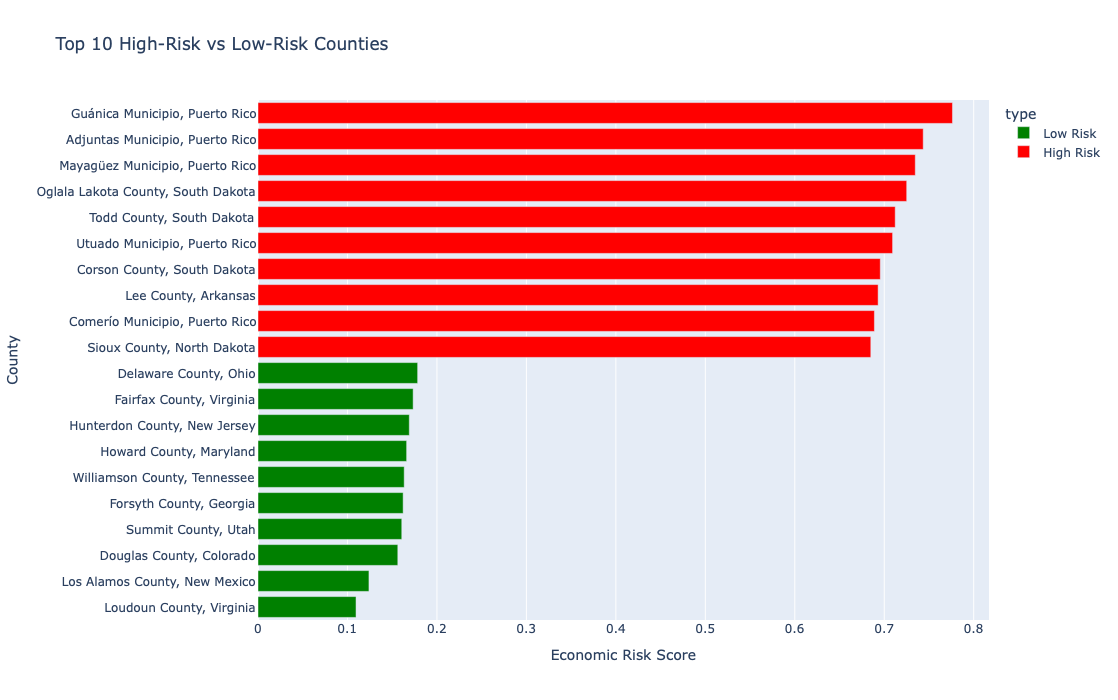

In [25]:
# -------------------------------------------------------
# Plotly Visualization: Top vs Bottom Risk Counties
# -------------------------------------------------------

import plotly.express as px

# Create copies to avoid SettingWithCopyWarning
top_risk_plot = top_risk.copy()
low_risk_plot = low_risk.copy()

top_risk_plot["type"] = "High Risk"
low_risk_plot["type"] = "Low Risk"

combined = combined.sort_values("economic_risk_score")
fig = px.bar(
    combined,
    x="economic_risk_score",
    y="county_name",
    color="type",
    orientation="h",
    title="Top 10 High-Risk vs Low-Risk Counties",
    labels={
        "economic_risk_score": "Economic Risk Score",
        "county_name": "County"
    },
    color_discrete_map={
        "Low Risk": "green",
        "High Risk": "red"
    }
)

fig.update_layout(height=700)

fig.show()

## Prepare Dataset for Streamlit Application

To support the Streamlit dashboard, we prepare a clean dataset by:

- Splitting county and state information
- Reorganizing columns for easier filtering and display

In [28]:
# -------------------------------------------------------
# Streamlit Prep: Split county_name into county + state
# -------------------------------------------------------

df_app = df.copy()

# Split "County, State"
parts = df_app["county_name"].str.rsplit(", ", n=1, expand=True)
df_app["county"] = parts[0]
df_app["state"] = parts[1]

# Reorder columns
cols_order = [
    "county_fips", "state", "county",
    "total_population", "median_household_income",
    "poverty_rate", "unemployment_rate",
    "homeownership_rate", "renter_rate",
    "bachelors_or_higher_pct",
    "economic_risk_score", "risk_category"
]

df_app = df_app[cols_order]

print("App dataset shape:", df_app.shape)
df_app.head()

App dataset shape: (3222, 12)


,county_fips,state,county,total_population,median_household_income,poverty_rate,unemployment_rate,homeownership_rate,renter_rate,bachelors_or_higher_pct,economic_risk_score,risk_category
0,1001,Alabama,Autauga County,59947,72481.0,0.112895,0.022899,0.770607,0.229393,0.291385,0.347077,Low Risk
1,1003,Alabama,Baldwin County,246989,78775.0,0.100927,0.030107,0.776036,0.223964,0.336895,0.328225,Low Risk
2,1005,Alabama,Barbour County,24643,46042.0,0.213826,0.077736,0.682406,0.317594,0.106273,0.514118,High Risk
3,1007,Alabama,Bibb County,22130,52541.0,0.224570,0.120808,0.791796,0.208204,0.117256,0.514312,High Risk
4,1009,Alabama,Blount County,59518,64190.0,0.128601,0.049971,0.809829,0.190171,0.158182,0.405978,Medium Risk
